In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter


df = pd.read_csv('students_data.csv')

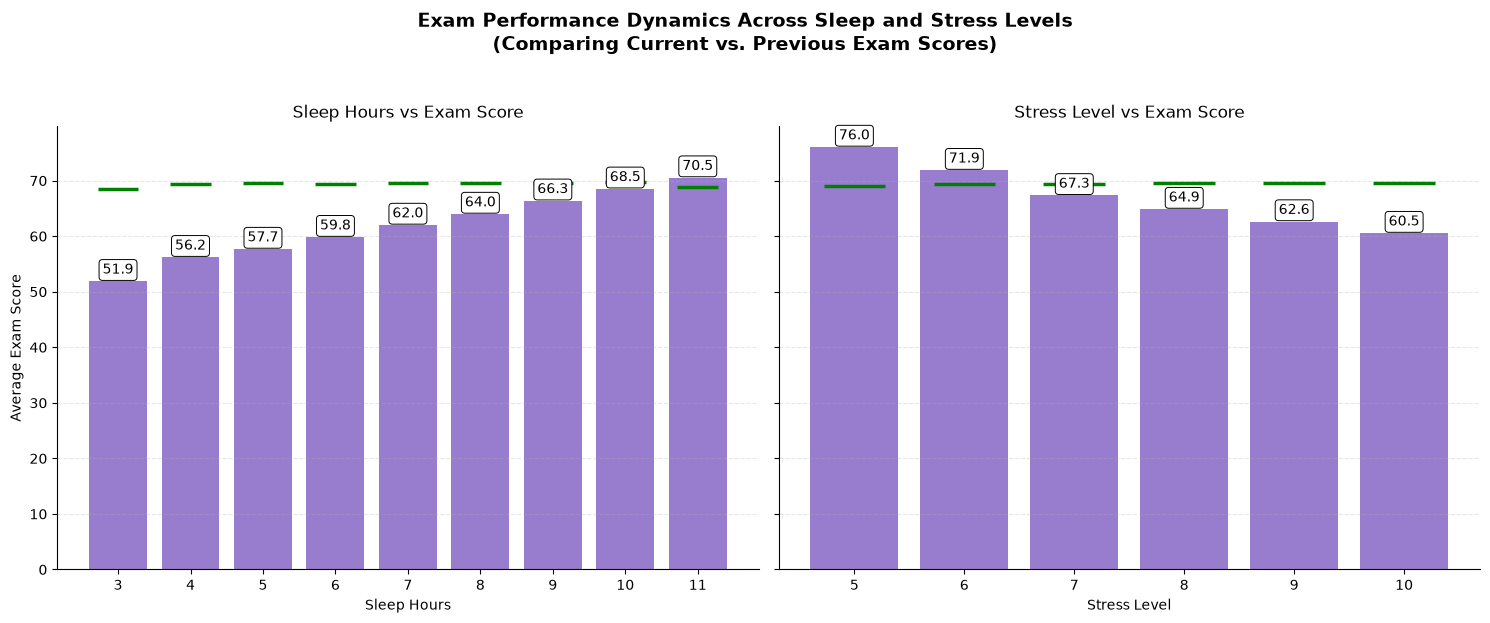

In [2]:
df2 = df.copy()

df2["sleep_group"] = np.floor(df2["sleep_hours"] + 0.5).astype(int)

sleep_score = (
    df2.groupby("sleep_group")[["exam_score", "previous_exam_score"]]
       .mean()
       .reset_index()
)

stress_score = (
    df2.groupby("stress_level")[["exam_score", "previous_exam_score"]]
       .mean()
       .reset_index()
)


fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

fig.suptitle(
    'Exam Performance Dynamics Across Sleep and Stress Levels\n'
    '(Comparing Current vs. Previous Exam Scores)',
    fontsize=14,
    fontweight='bold',
    y=1.03,
)

for ax, data, x_col, title, xlabel in [
    (axes[0], sleep_score, "sleep_group",
     "Sleep Hours vs Exam Score", "Sleep Hours"),

    (axes[1], stress_score, "stress_level",
     "Stress Level vs Exam Score", "Stress Level")
]:

    sns.barplot(
        data=data,
        x=x_col,
        y="exam_score",
        color="mediumpurple",
        ax=ax
    )

    for bar in ax.patches:
        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.8,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="black",
                linewidth=0.7
            )
        )

    # Previous score
    for i, previous in enumerate(data["previous_exam_score"]):

        ax.hlines(
        y=previous,
        xmin=i - 0.28,
        xmax=i + 0.28,
        linewidth=2.5,
        color="green"
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", linestyle="--", alpha=0.3)


axes[0].set_ylabel("Average Exam Score")
axes[1].set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()